In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import scipy
import sklearn
from tensorflow.keras.datasets import mnist
from sklearn.datasets import load_iris
from sklearn.datasets import load_digits


print("All libraries imported successfully!")

All libraries imported successfully!


Shape: (150, 5)

Summary Statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Class Distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing Values:
 sepal length (cm)

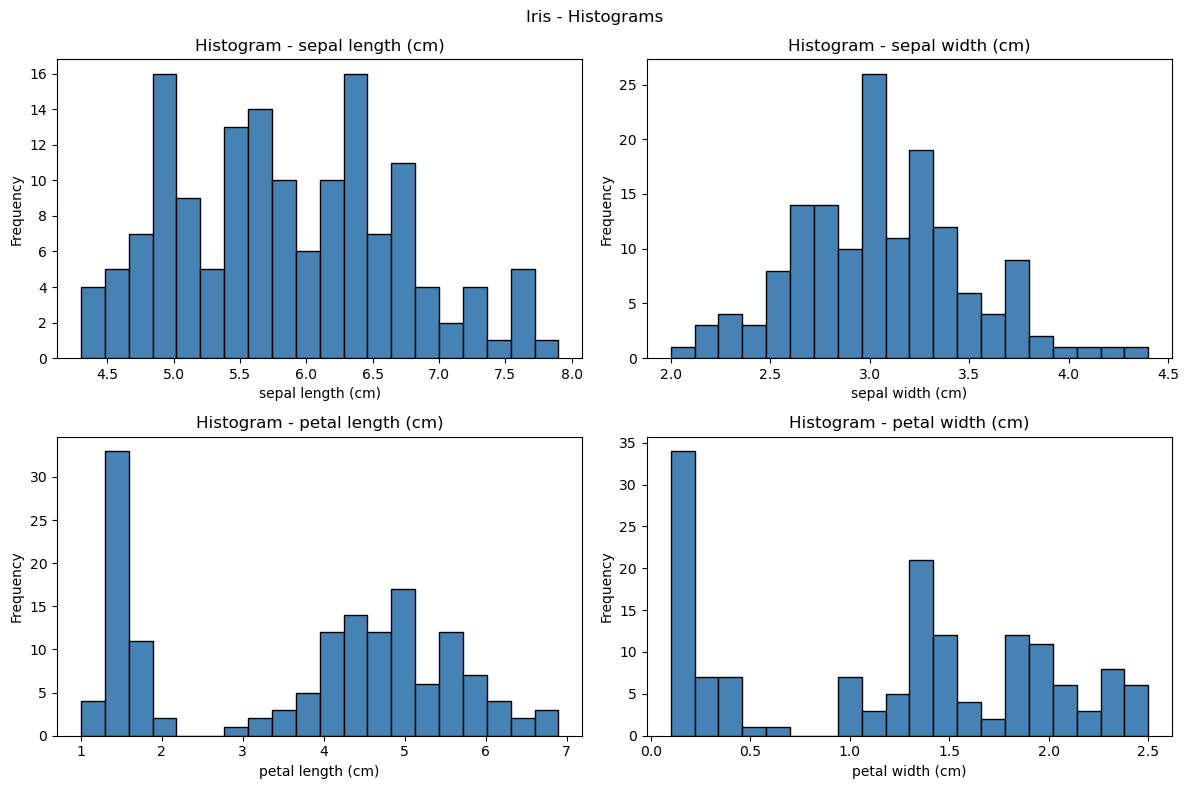

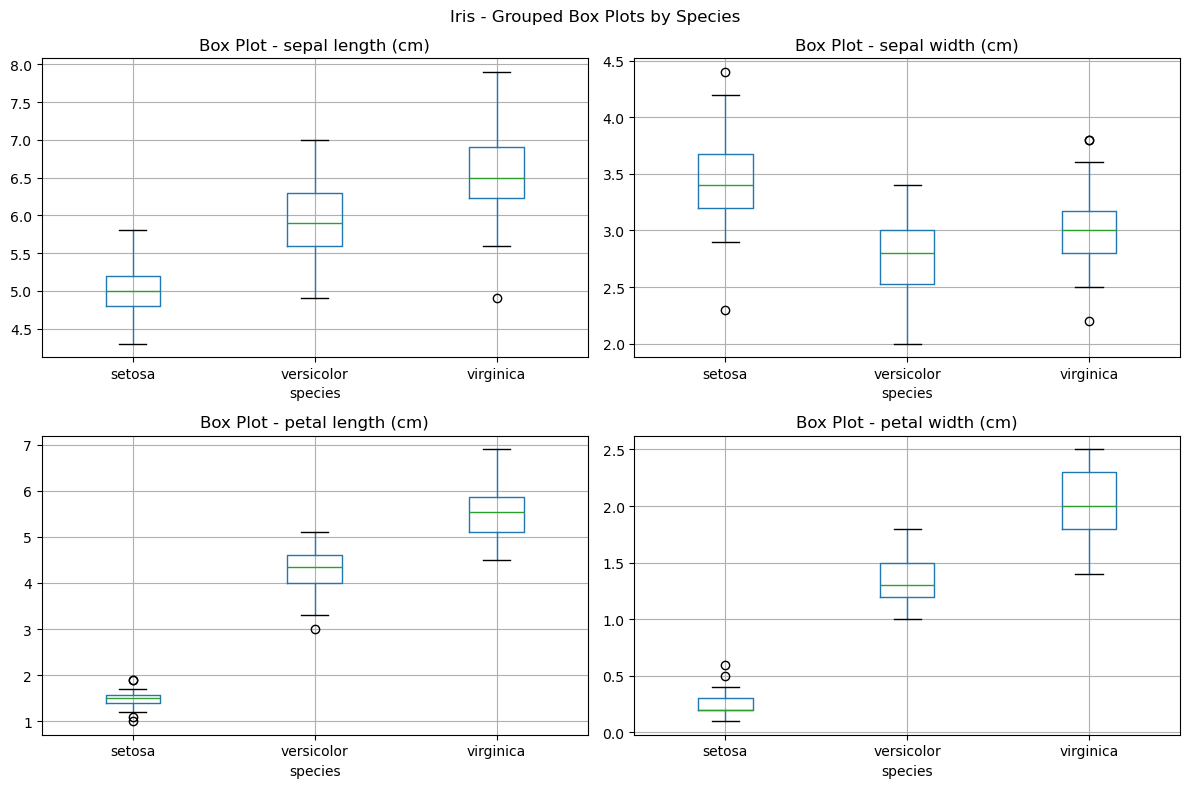

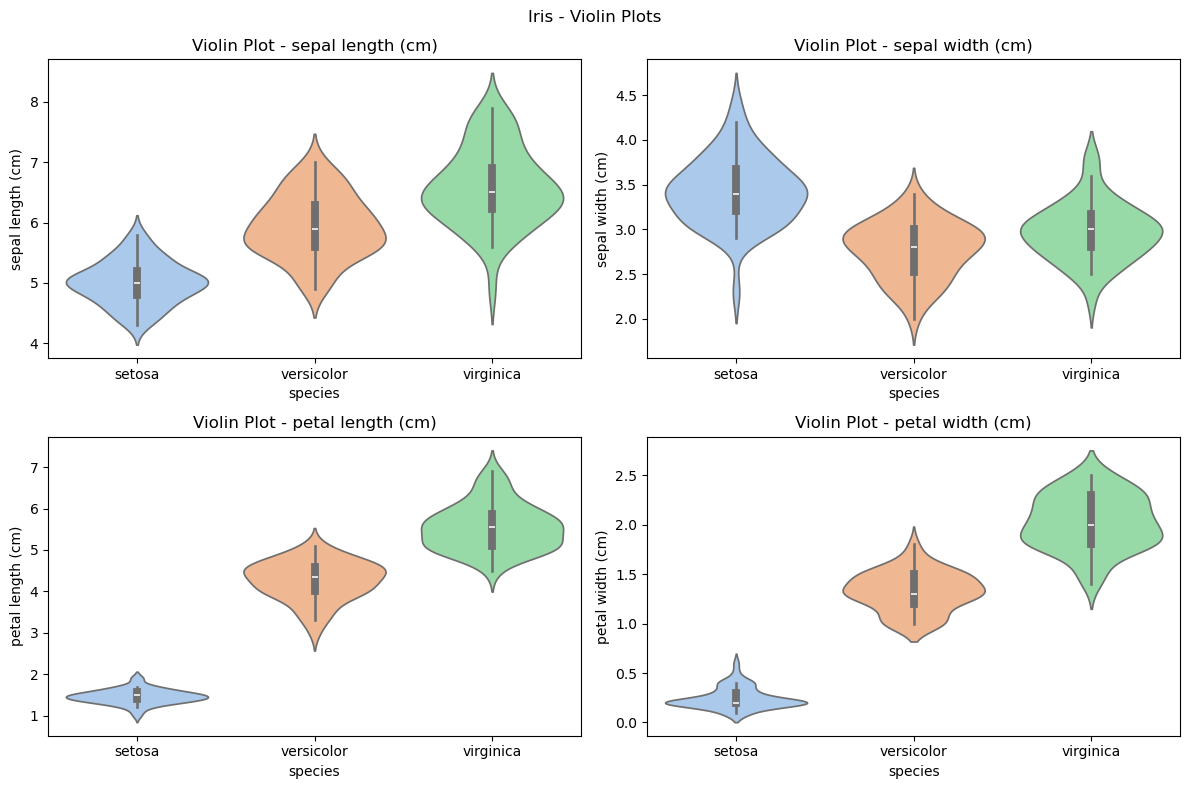

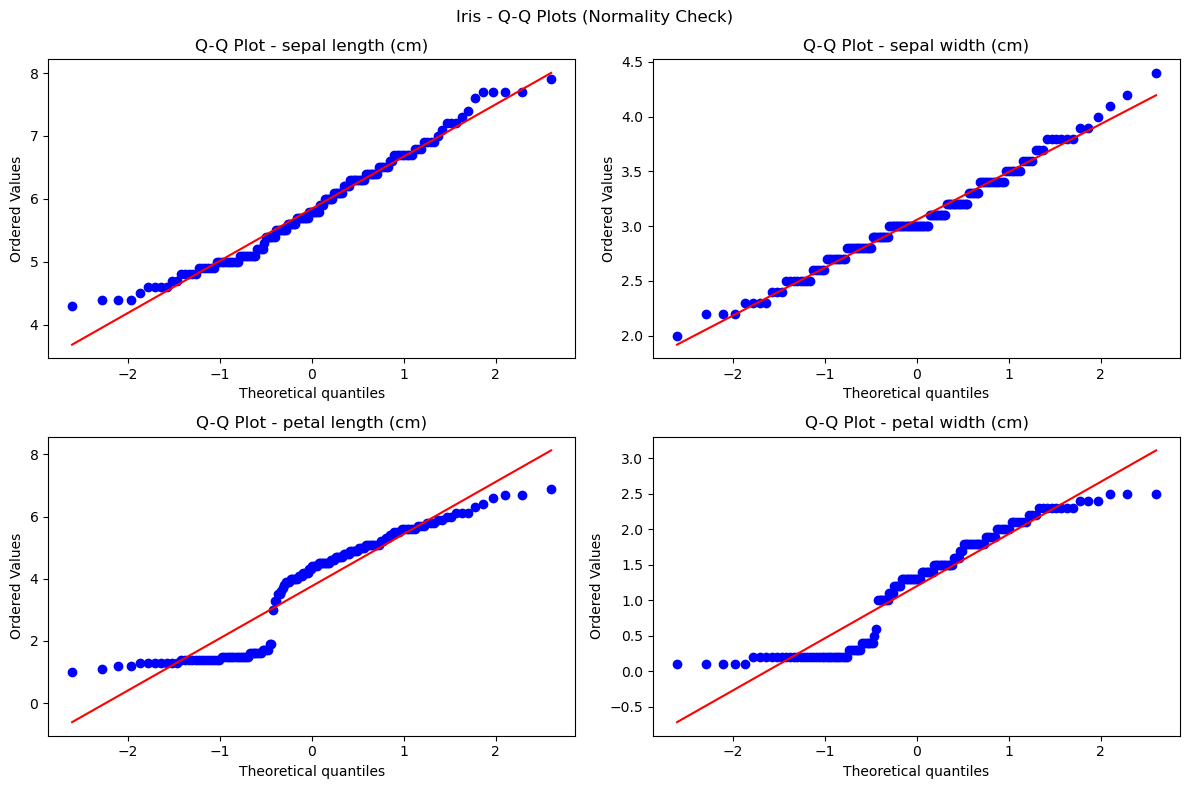

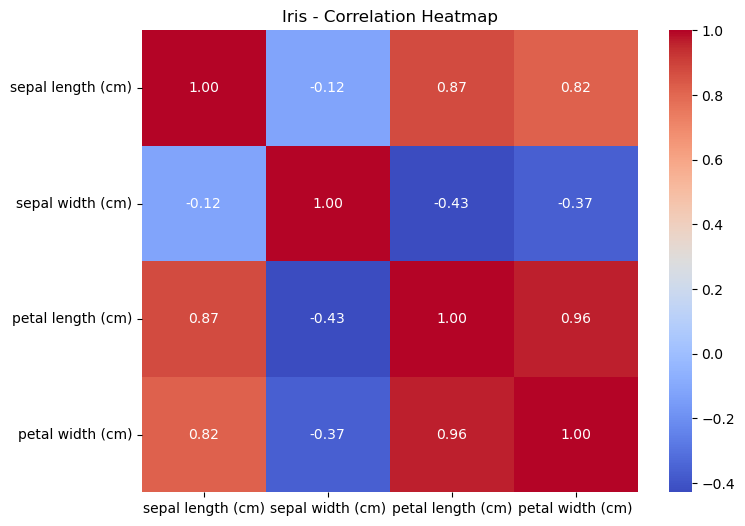

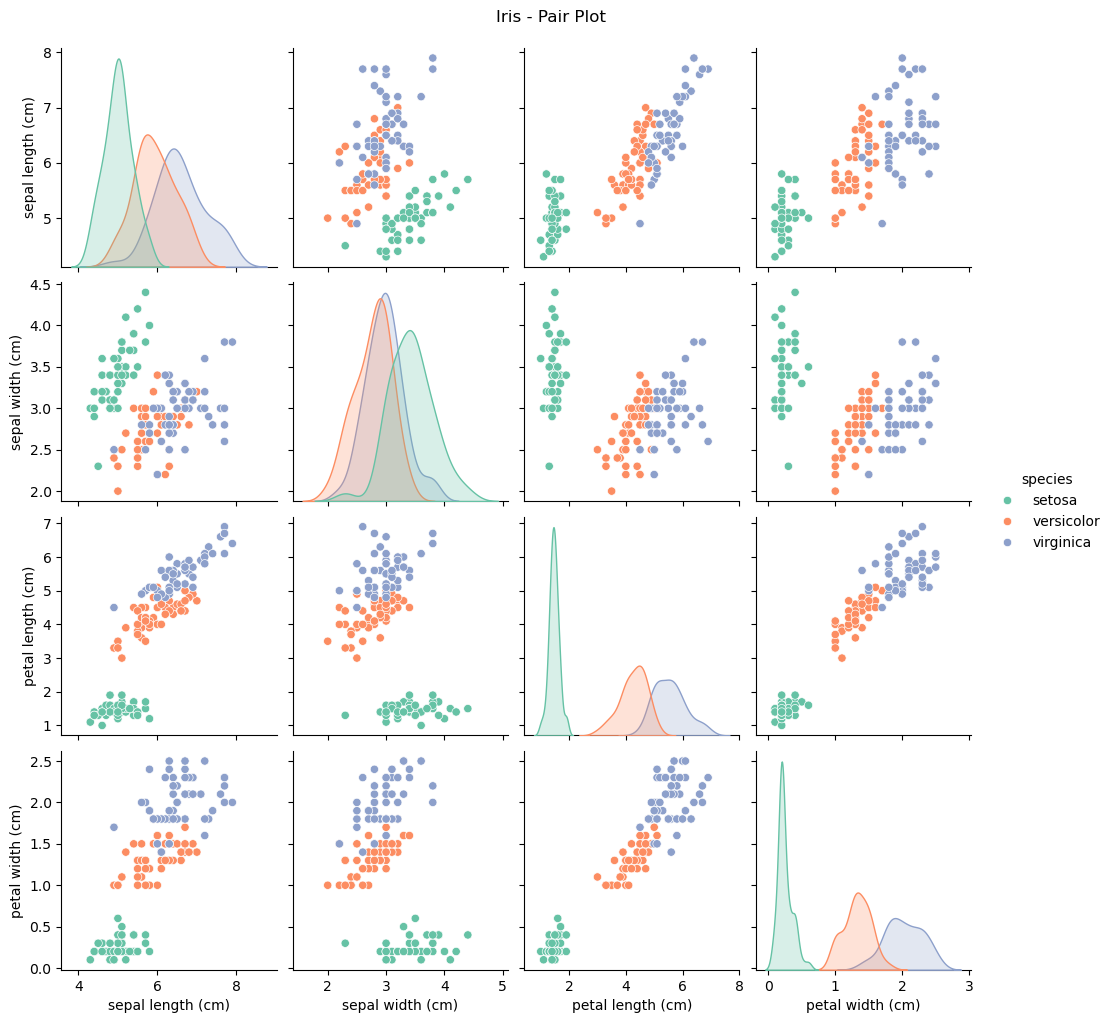

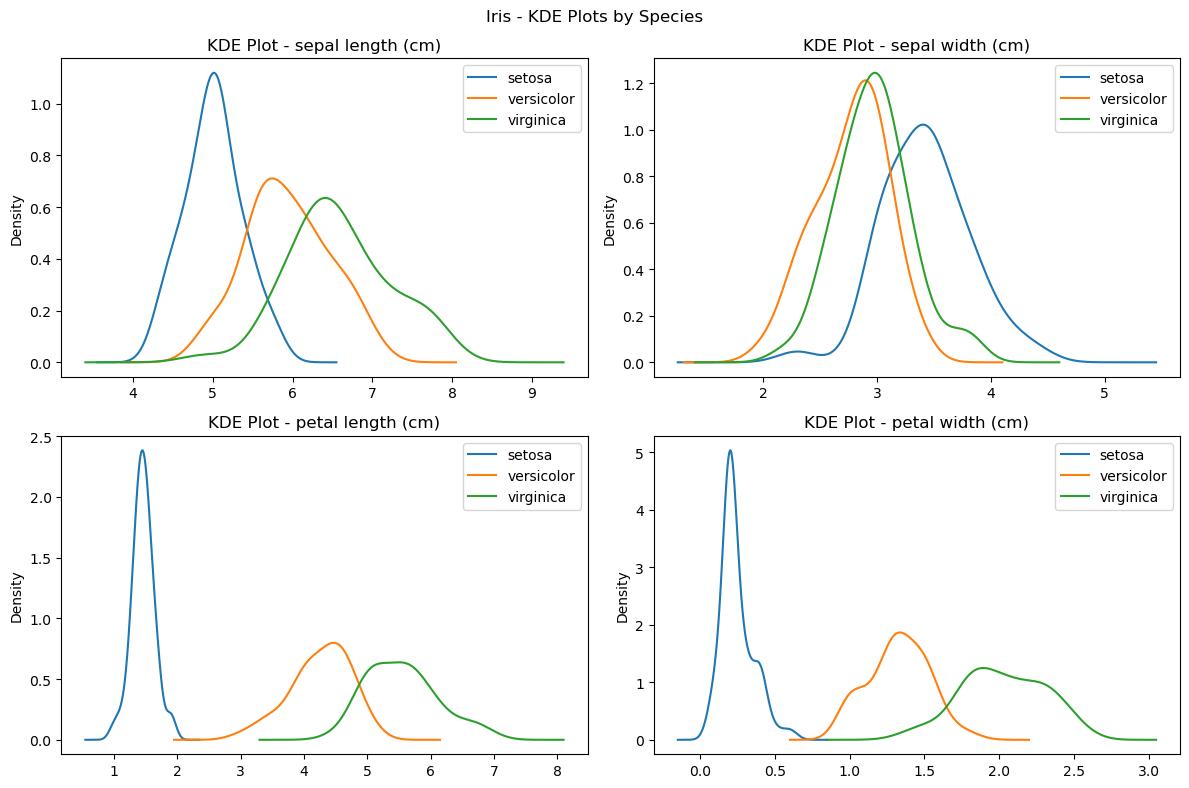


Outlier Detection using IQR Method:
  sepal length (cm): 0 outliers
  sepal width (cm): 4 outliers
  petal length (cm): 0 outliers
  petal width (cm): 0 outliers


In [26]:

# EDA - IRIS DATASET

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Shape:", df.shape)
print("\nSummary Statistics:\n", df.describe())
print("\nClass Distribution:\n", df['species'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(iris.feature_names):
    ax = axes[i//2, i%2]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='black')
    ax.set_title(f"Histogram - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.suptitle("Iris - Histograms")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(iris.feature_names):
    ax = axes[i//2, i%2]
    df.boxplot(column=col, by='species', ax=ax)
    ax.set_title(f"Box Plot - {col}")
plt.suptitle("Iris - Grouped Box Plots by Species")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(iris.feature_names):
    ax = axes[i//2, i%2]
    sns.violinplot(
    x='species',
    y=col,
    data=df,
    ax=ax,
    hue='species',
    palette='pastel',
    legend=False
)
    ax.set_title(f"Violin Plot - {col}")
plt.suptitle("Iris - Violin Plots")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(iris.feature_names):
    ax = axes[i//2, i%2]
    stats.probplot(df[col], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot - {col}")
plt.suptitle("Iris - Q-Q Plots (Normality Check)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Iris - Correlation Heatmap")
plt.show()

sns.pairplot(df, hue='species', vars=iris.feature_names, palette='Set2')
plt.suptitle("Iris - Pair Plot", y=1.02)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(iris.feature_names):
    ax = axes[i//2, i%2]
    for species in df['species'].unique():
        df[df['species'] == species][col].plot.kde(ax=ax, label=species)
    ax.set_title(f"KDE Plot - {col}")
    ax.legend()
plt.suptitle("Iris - KDE Plots by Species")
plt.tight_layout()
plt.show()

print("\nOutlier Detection using IQR Method:")
for col in iris.feature_names:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col}: {len(outliers)} outliers")

Shape: (614, 13)

First 5 rows:
     Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural  

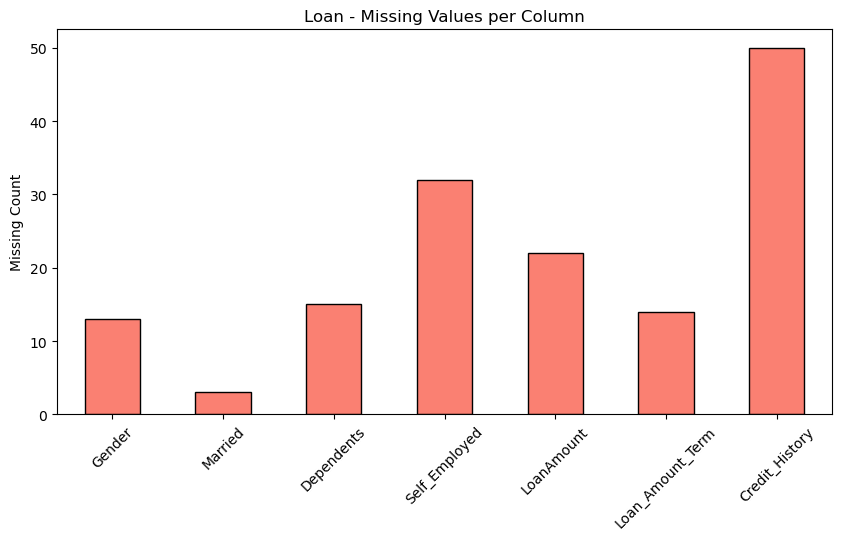

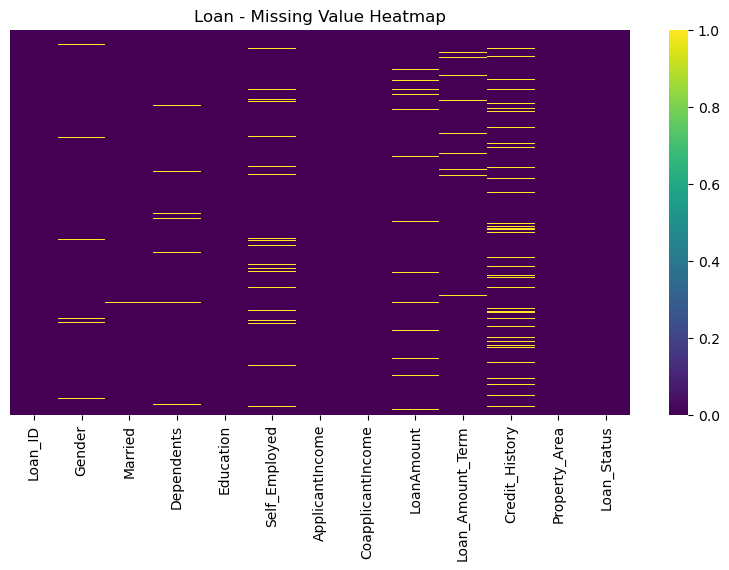

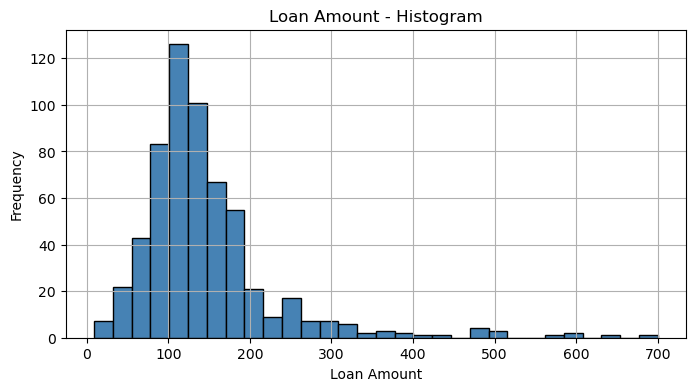

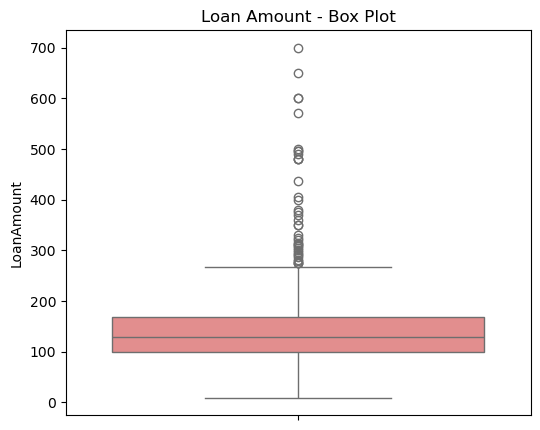


Outliers in LoanAmount (IQR Method): 39


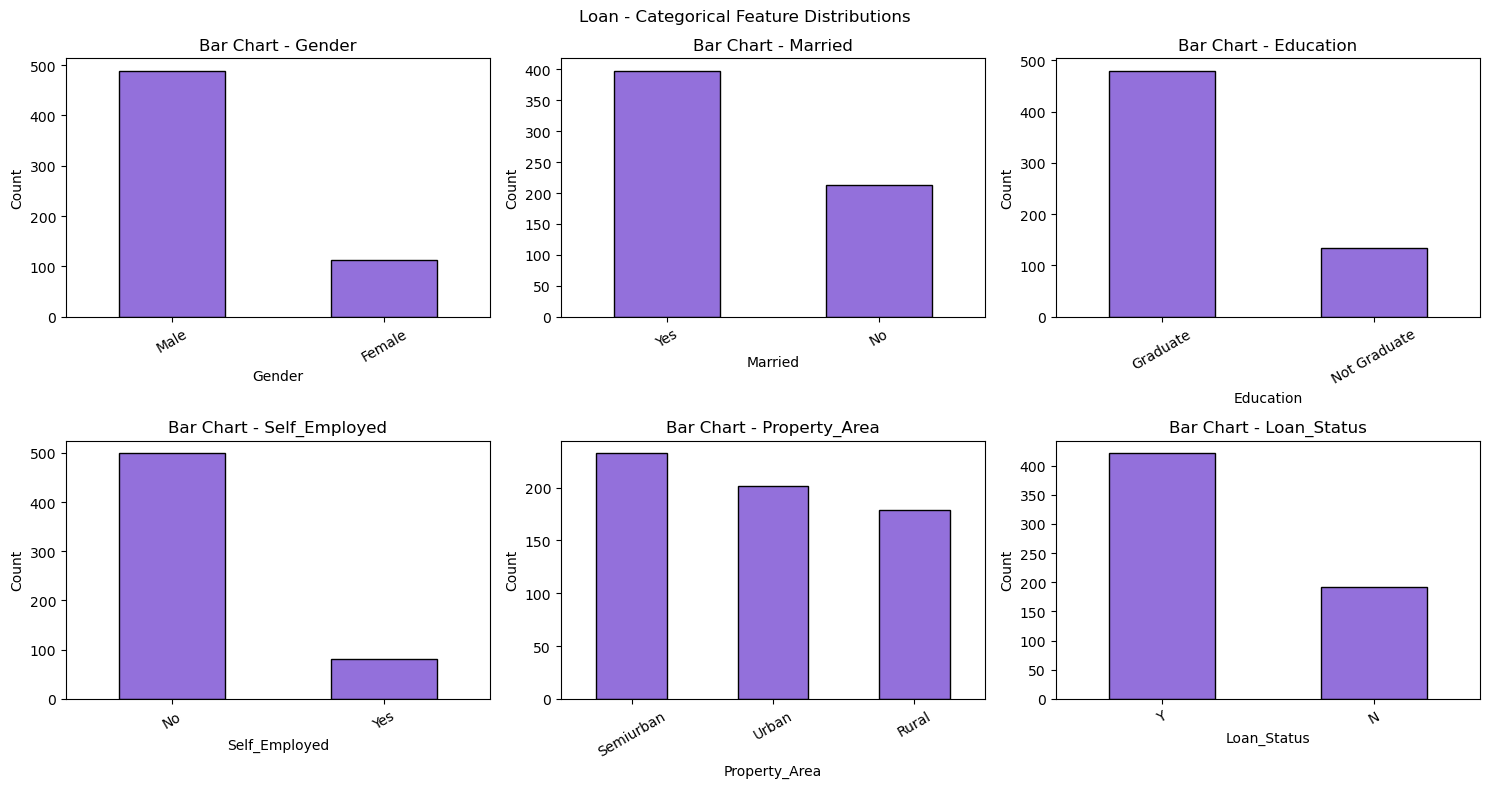

/tmp/ipykernel_8325/1751446336.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='LoanAmount', data=df, ax=axes[0], palette='Set3')


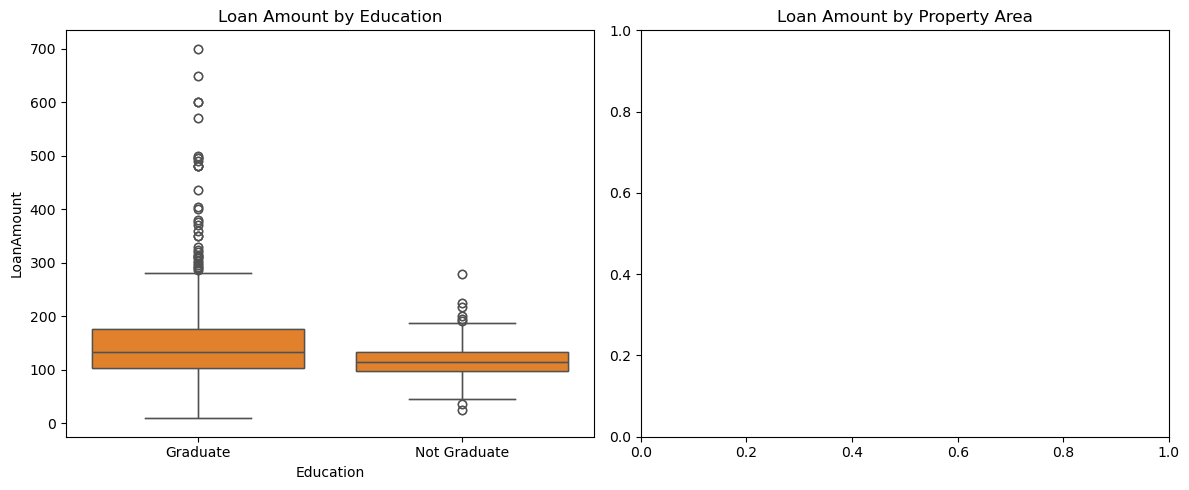

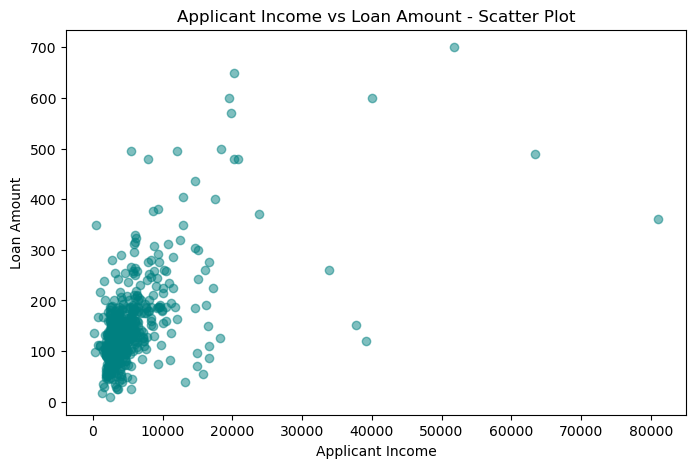

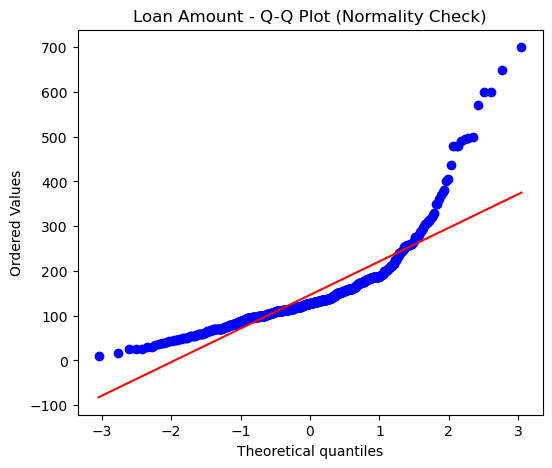

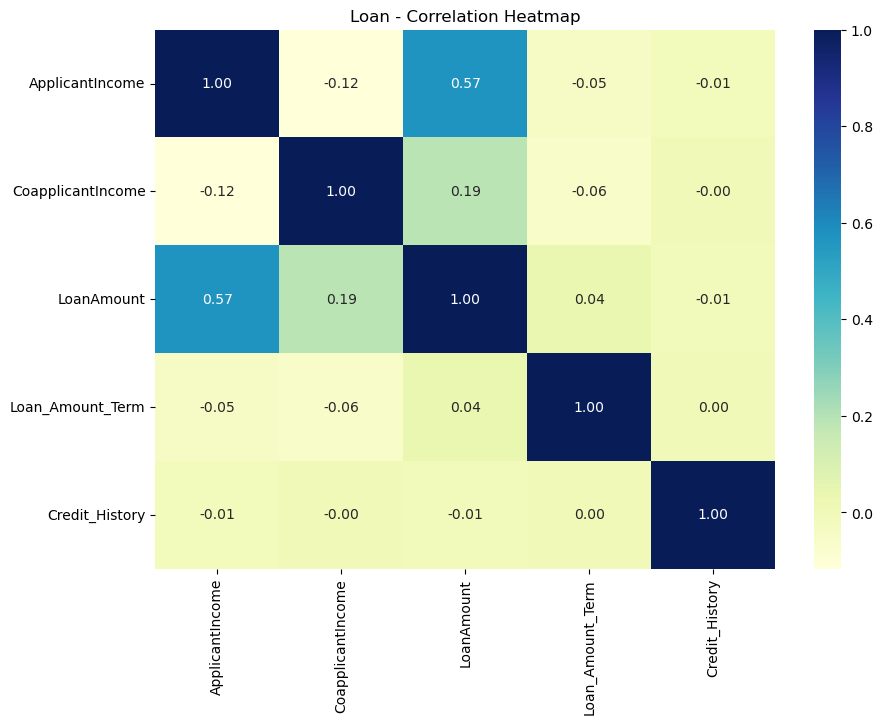

In [14]:
# ============================================================
# EDA - LOAN AMOUNT PREDICTION

df = pd.read_csv('loantrain.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

missing = df.isnull().sum()
missing = missing[missing > 0]
plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Loan - Missing Values per Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title("Loan - Missing Value Heatmap")
plt.show()

plt.figure(figsize=(8, 4))
df['LoanAmount'].dropna().hist(bins=30, color='steelblue', edgecolor='black')
plt.title("Loan Amount - Histogram")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(y=df['LoanAmount'], color='lightcoral')
plt.title("Loan Amount - Box Plot")
plt.show()

Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['LoanAmount'] < Q1 - 1.5*IQR) | (df['LoanAmount'] > Q3 + 1.5*IQR)]
print(f"\nOutliers in LoanAmount (IQR Method): {len(outliers)}")

cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(cat_cols):
    ax = axes[i//3, i%3]
    df[col].value_counts().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
    ax.set_title(f"Bar Chart - {col}")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
plt.suptitle("Loan - Categorical Feature Distributions")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Education', y='LoanAmount', data=df, ax=axes[0], palette='Set3')
axes[0].set_title("Loan Amount by Education")
sns.boxplot(
    x='Education',
    y='LoanAmount',
    data=df,
    ax=axes[0]
)
axes[1].set_title("Loan Amount by Property Area")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['ApplicantIncome'], df['LoanAmount'], alpha=0.5, color='teal')
plt.title("Applicant Income vs Loan Amount - Scatter Plot")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

plt.figure(figsize=(6, 5))
stats.probplot(df['LoanAmount'].dropna(), dist="norm", plot=plt)
plt.title("Loan Amount - Q-Q Plot (Normality Check)")
plt.show()

num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Loan - Correlation Heatmap")
plt.show()

Shape: (768, 9)

Summary Statistics:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951

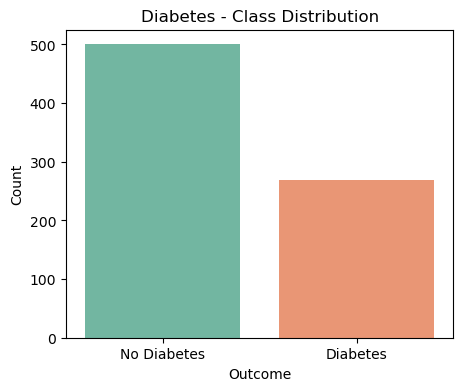

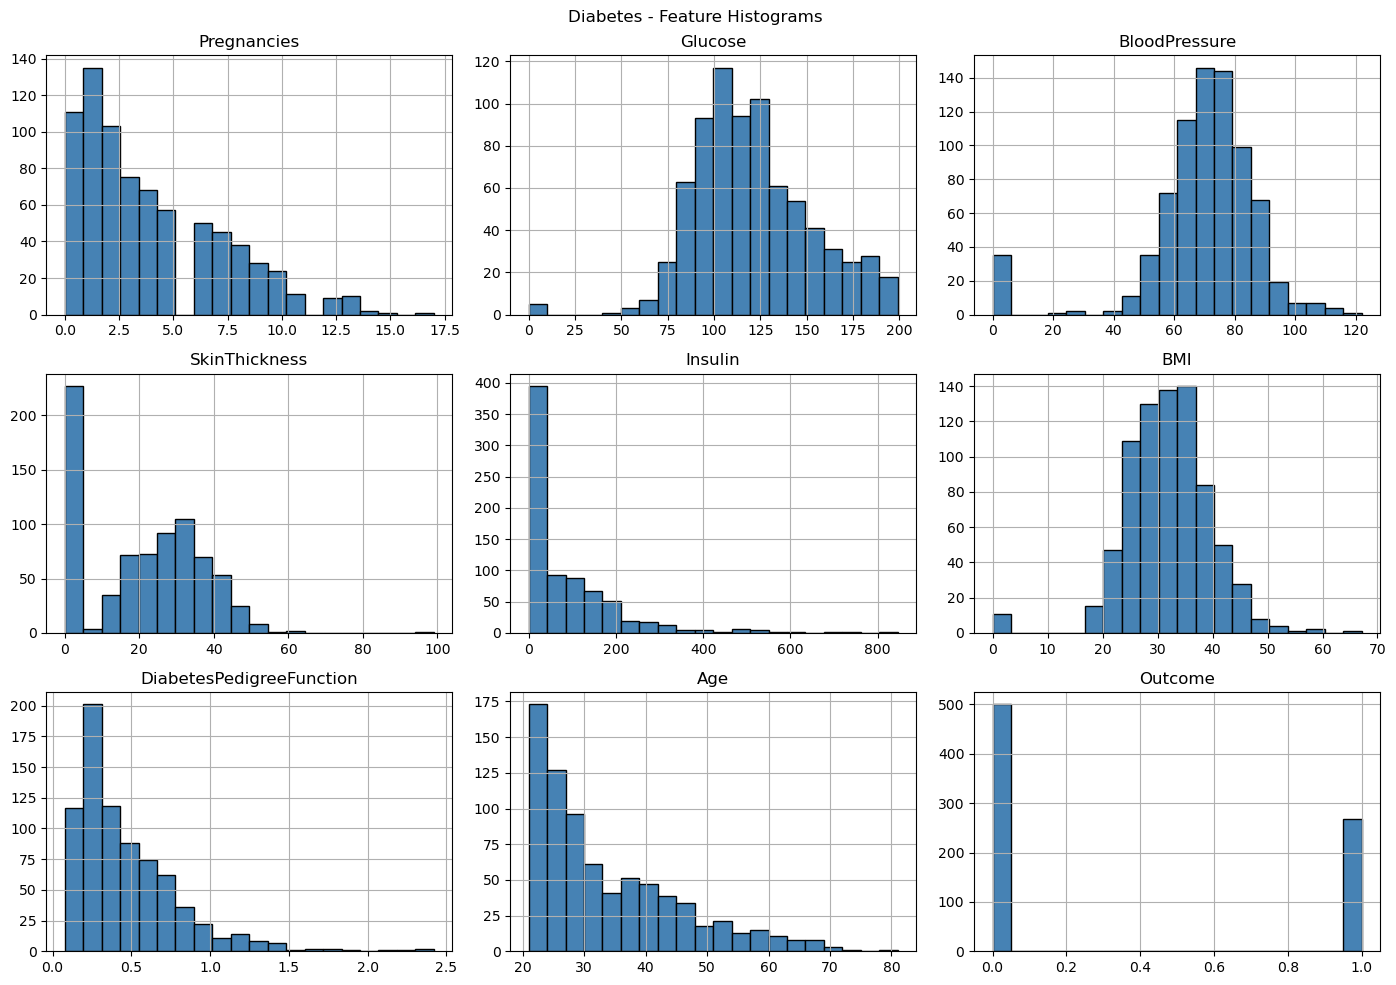

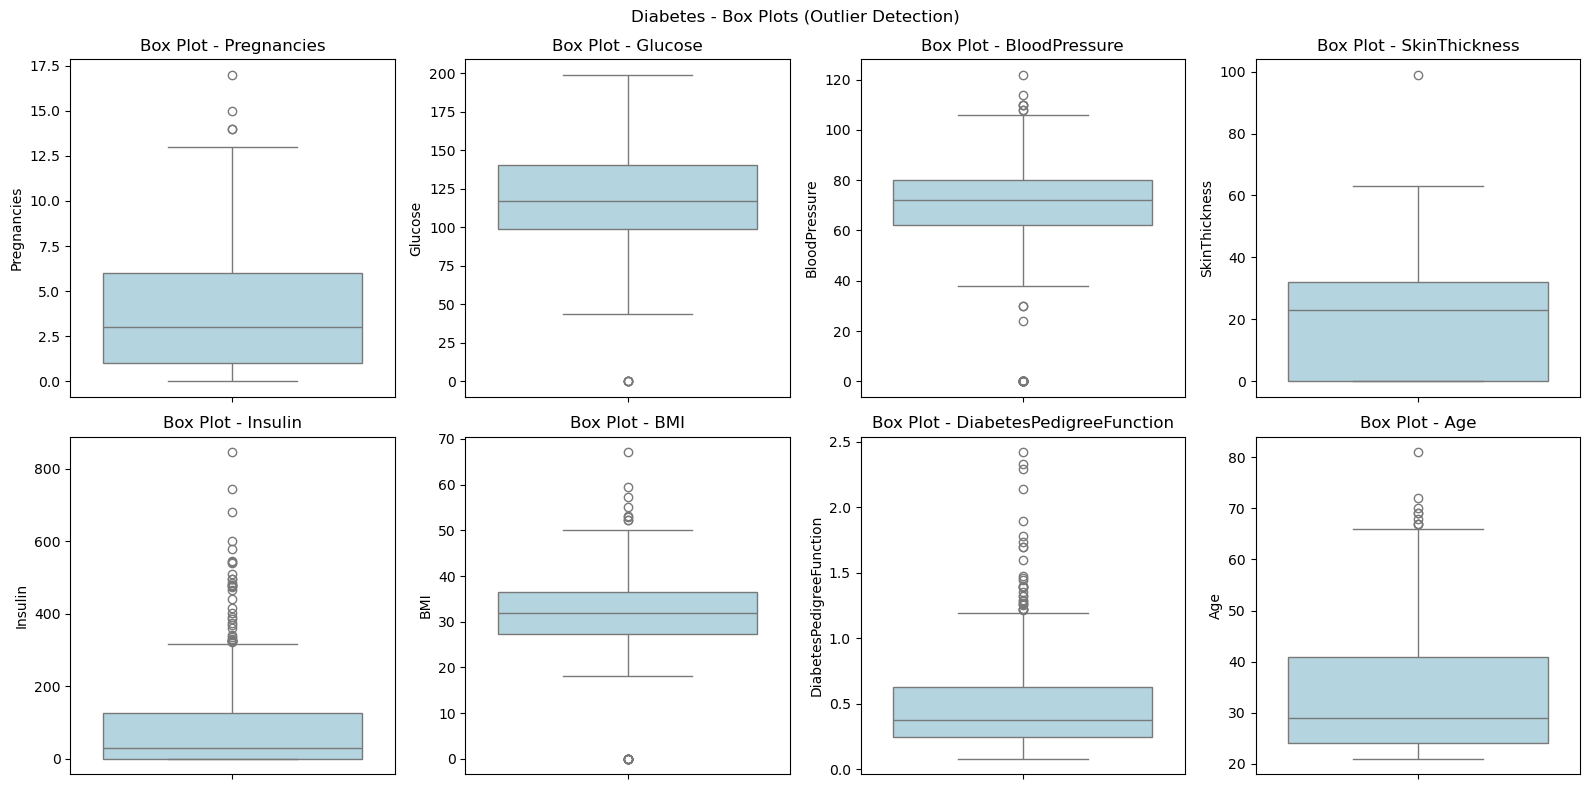


Outlier Detection using IQR Method:
Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers


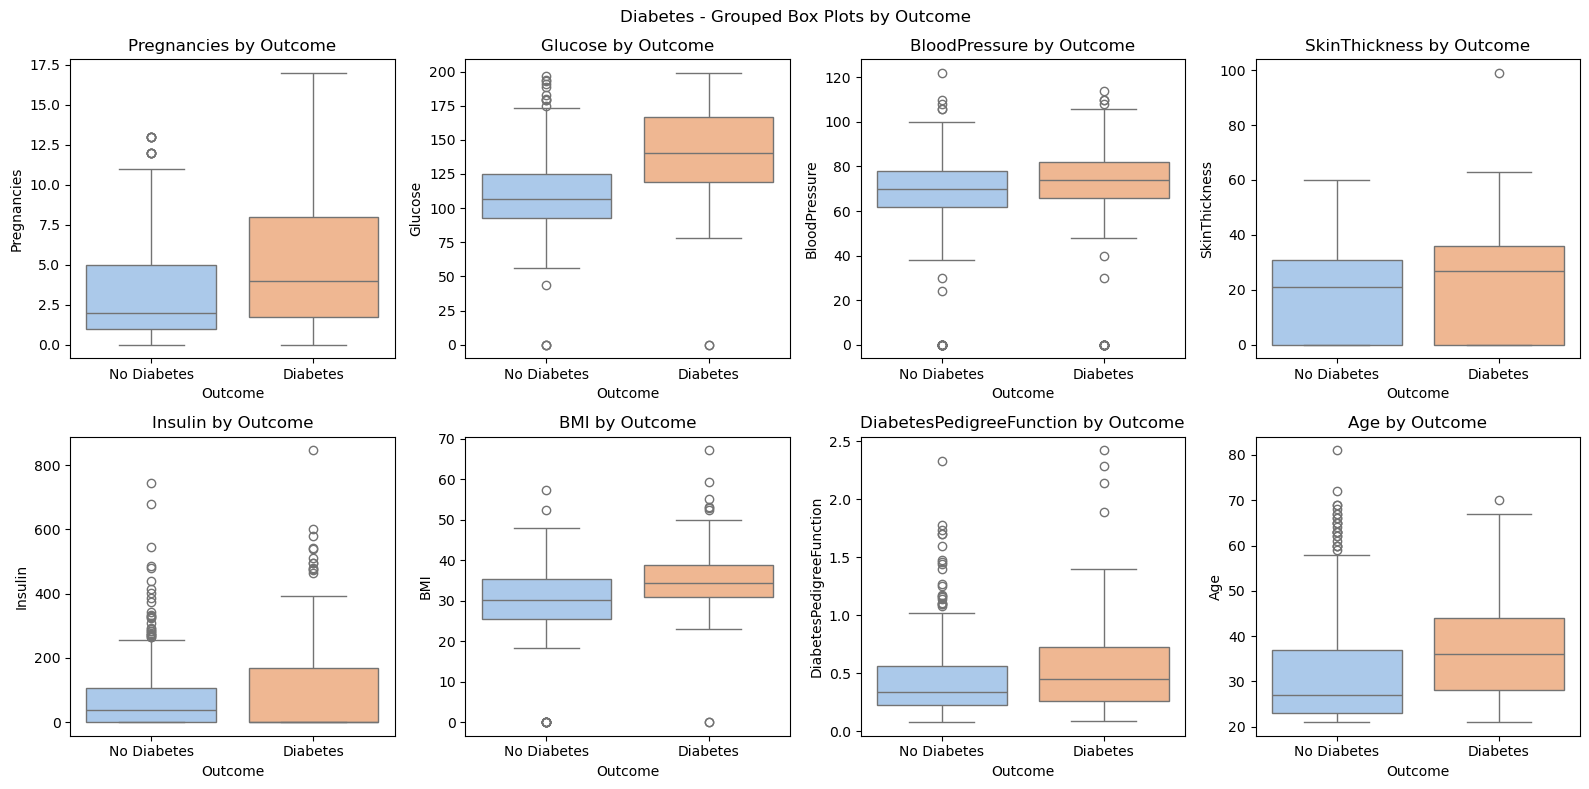

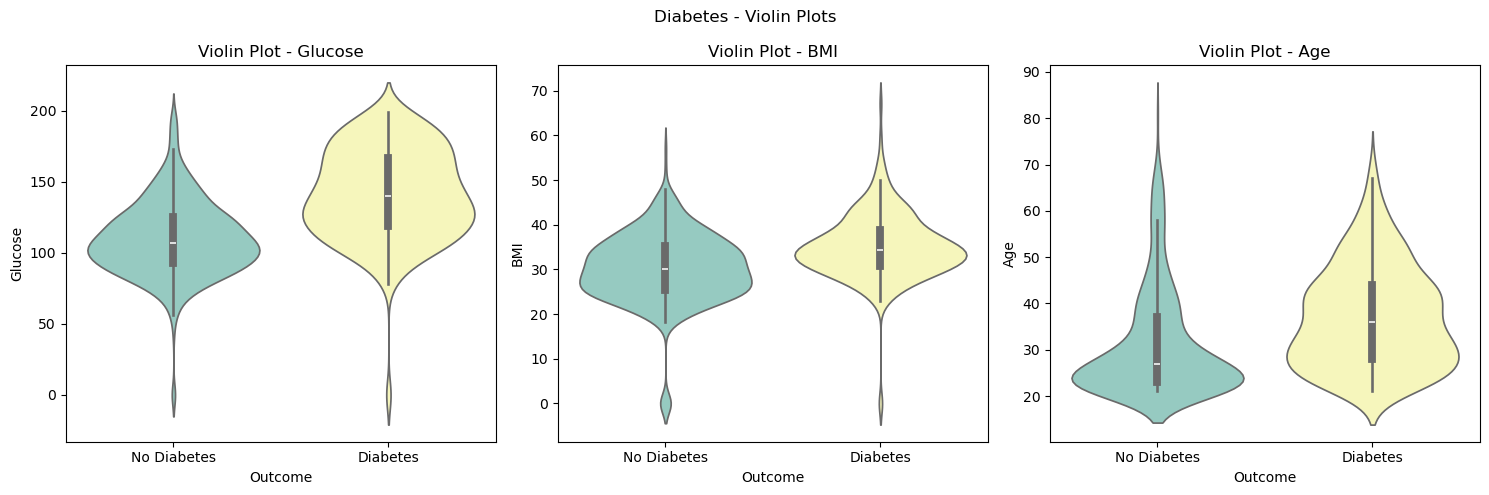

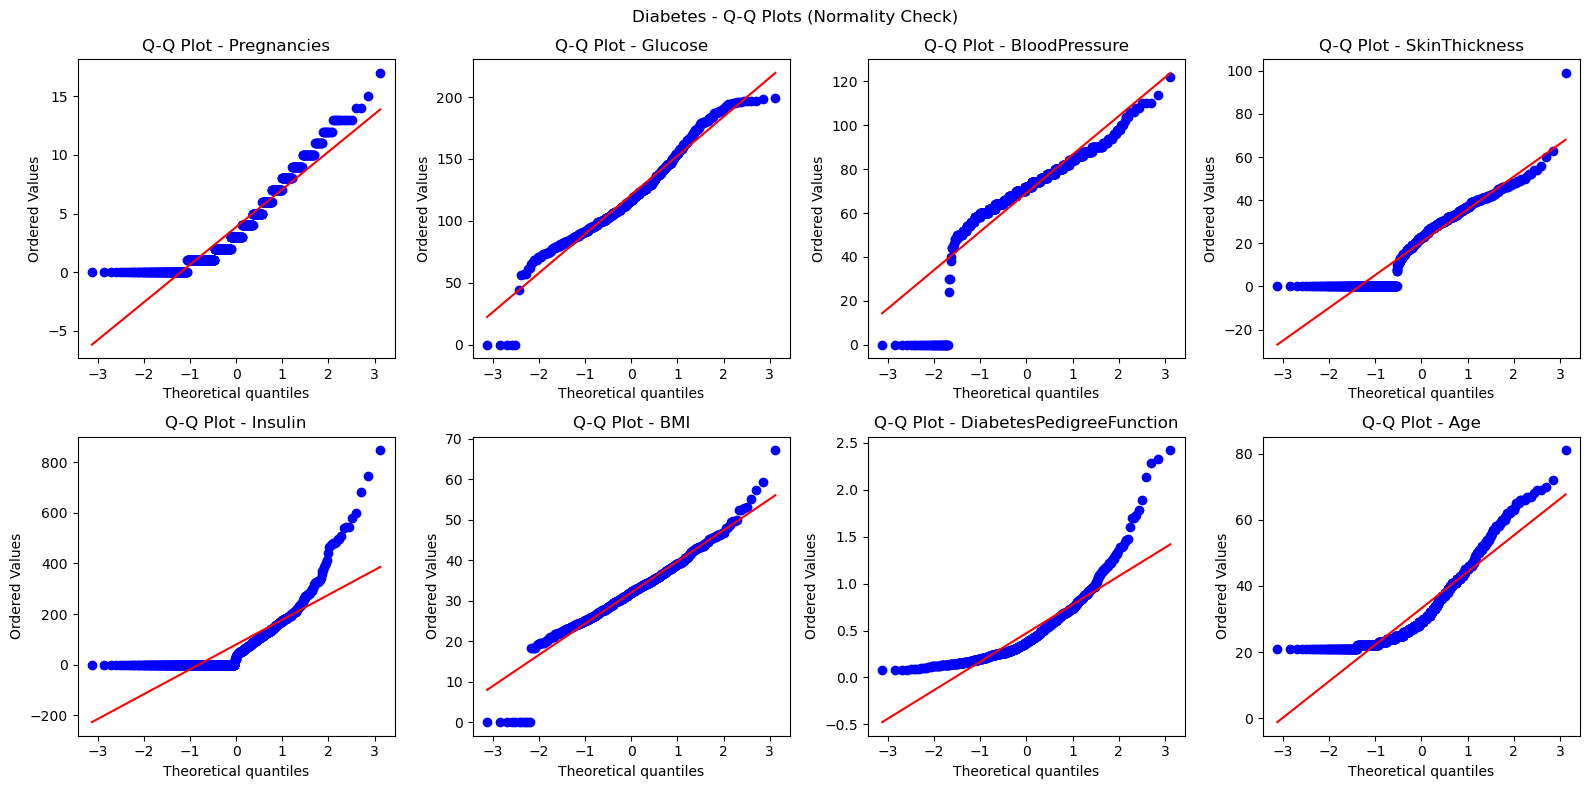

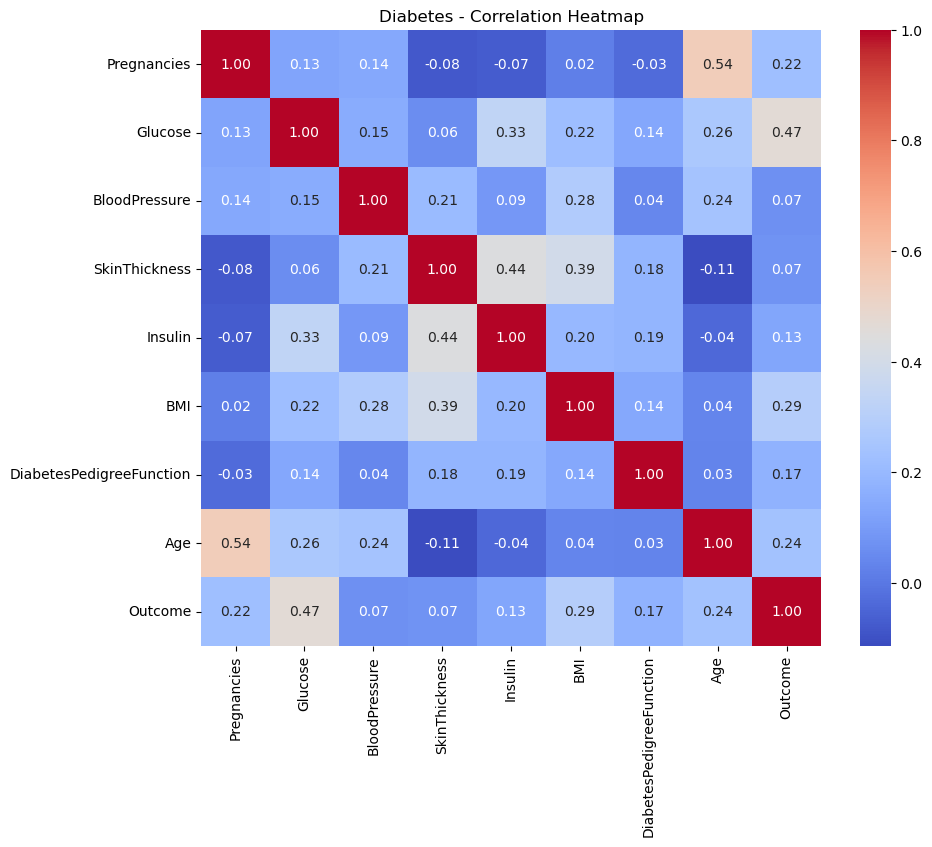

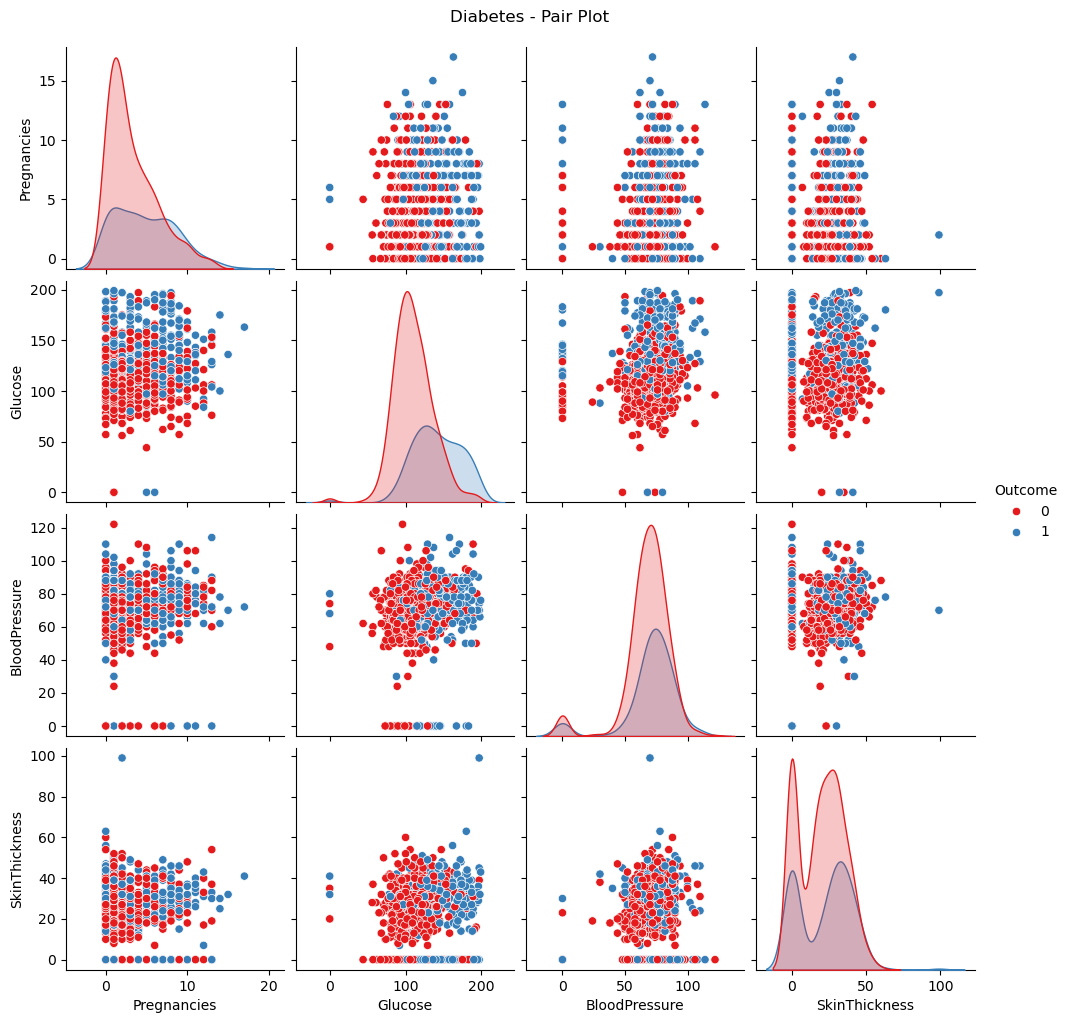

In [27]:
# ============================================================
# EDA - DIABETES PREDICTION

df = pd.read_csv('diabetes.csv')

print("Shape:", df.shape)
print("\nSummary Statistics:\n", df.describe())
print("\nClass Distribution (0=No, 1=Yes):\n", df['Outcome'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())

# -------------------------------
# Class Distribution
# -------------------------------
plt.figure(figsize=(5, 4))
sns.countplot(
    x='Outcome',
    hue='Outcome',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Diabetes - Class Distribution")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.ylabel("Count")
plt.show()

# -------------------------------
# Histograms
# -------------------------------
df.hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle("Diabetes - Feature Histograms")
plt.tight_layout()
plt.show()

# -------------------------------
# Box Plots (Outlier Detection)
# -------------------------------
features = df.columns[:-1]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(features):
    ax = axes[i // 4, i % 4]
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(f"Box Plot - {col}")

plt.suptitle("Diabetes - Box Plots (Outlier Detection)")
plt.tight_layout()
plt.show()

# -------------------------------
# Outlier Detection using IQR
# -------------------------------
print("\nOutlier Detection using IQR Method:")

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    print(f"{col}: {len(outliers)} outliers")

# -------------------------------
# Grouped Box Plots
# -------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(features):
    ax = axes[i // 4, i % 4]

    sns.boxplot(
        x='Outcome',
        y=col,
        hue='Outcome',
        data=df,
        palette='pastel',
        legend=False,
        ax=ax
    )

    ax.set_title(f"{col} by Outcome")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Diabetes', 'Diabetes'])

plt.suptitle("Diabetes - Grouped Box Plots by Outcome")
plt.tight_layout()
plt.show()

# -------------------------------
# Violin Plots
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['Glucose', 'BMI', 'Age']):
    sns.violinplot(
        x='Outcome',
        y=col,
        hue='Outcome',
        data=df,
        palette='Set3',
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"Violin Plot - {col}")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'])

plt.suptitle("Diabetes - Violin Plots")
plt.tight_layout()
plt.show()

# -------------------------------
# Q-Q Plots
# -------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(features):
    ax = axes[i // 4, i % 4]
    stats.probplot(df[col], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot - {col}")

plt.suptitle("Diabetes - Q-Q Plots (Normality Check)")
plt.tight_layout()
plt.show()

# -------------------------------
# Correlation Heatmap
# -------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Diabetes - Correlation Heatmap")
plt.show()

# -------------------------------
# Pair Plot
# -------------------------------
sns.pairplot(
    df,
    hue='Outcome',
    vars=list(features[:4]),
    palette='Set1'
)

plt.suptitle("Diabetes - Pair Plot", y=1.02)
plt.show()

Shape: (4601, 59)

Class Distribution:
 class
Ham     2788
Spam    1813
Name: count, dtype: int64

Missing Values: 0

Summary Statistics:
          feature_0    feature_1    feature_2    feature_3    feature_4  \
count  4601.000000  4601.000000  4601.000000  4601.000000  4601.000000   
mean      0.104553     0.213015     0.280656     0.065425     0.312223   
std       0.305358     1.290575     0.504143     1.395151     0.672513   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       0.000000     0.000000     0.420000     0.000000     0.380000   
max       4.540000    14.280000     5.100000    42.810000    10.000000   

         feature_5    feature_6    feature_7    feature_8    feature_9  ...  \
count  4601.000000  4601.000000  4601.000000  4601.000000  4601.000000  ...   
mean      0.095901     0.114208     

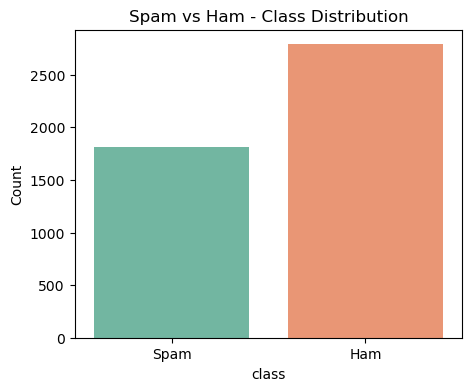

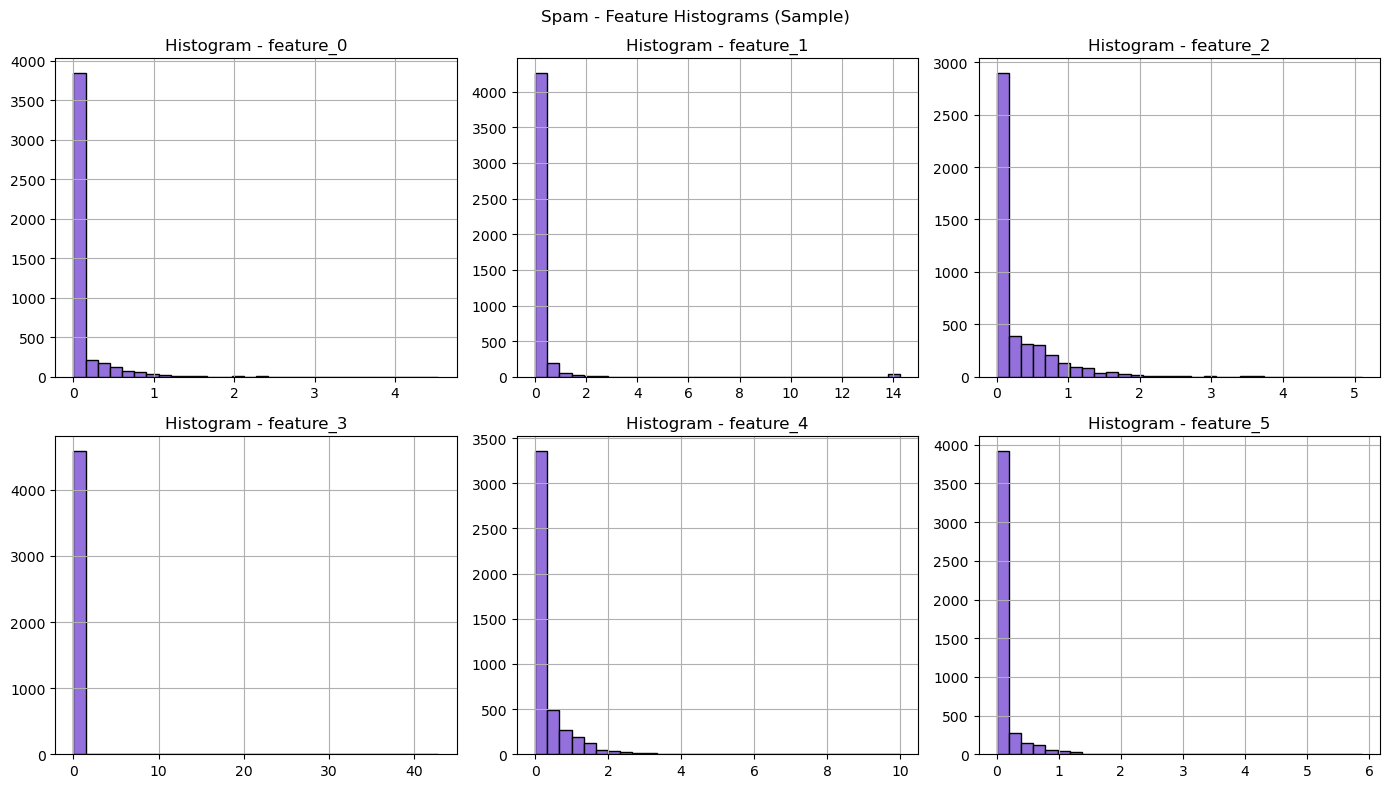

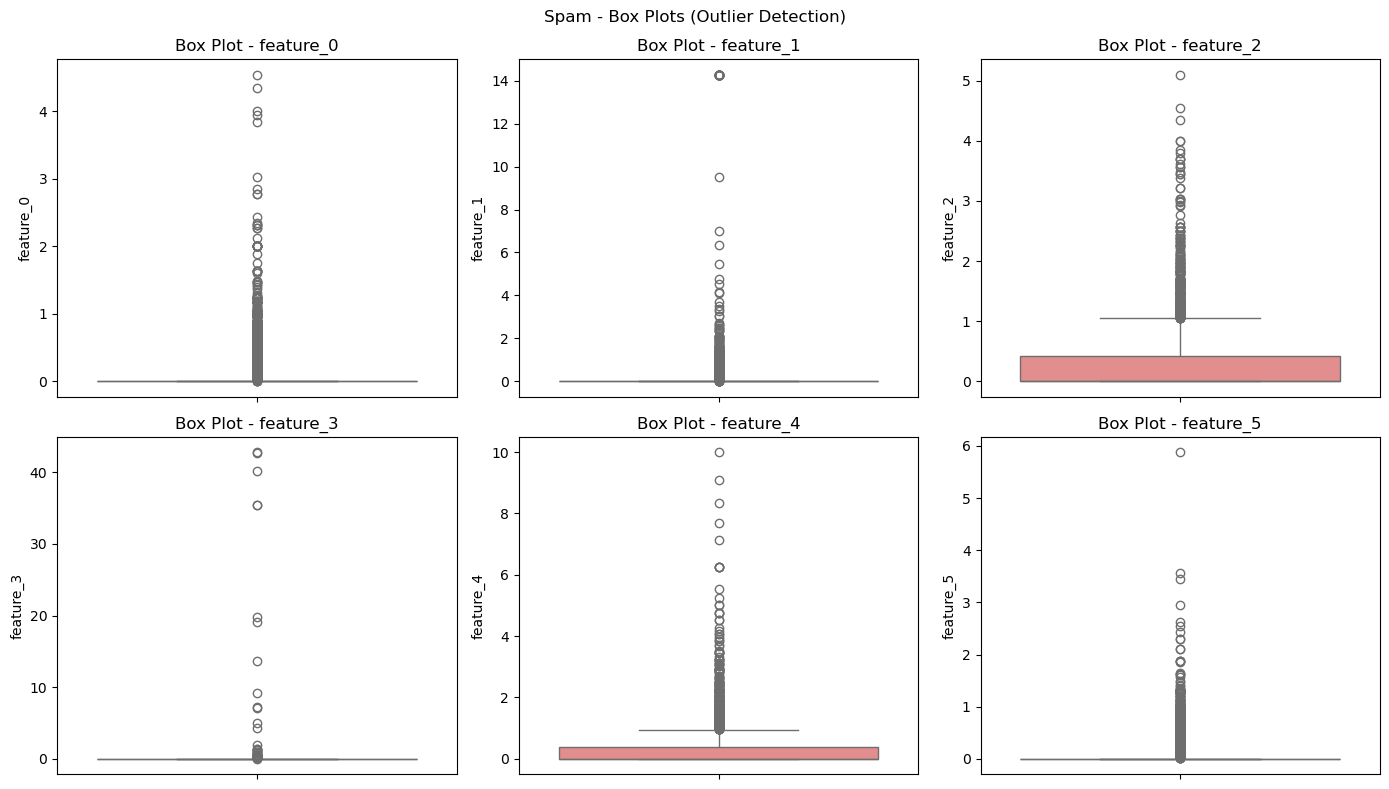

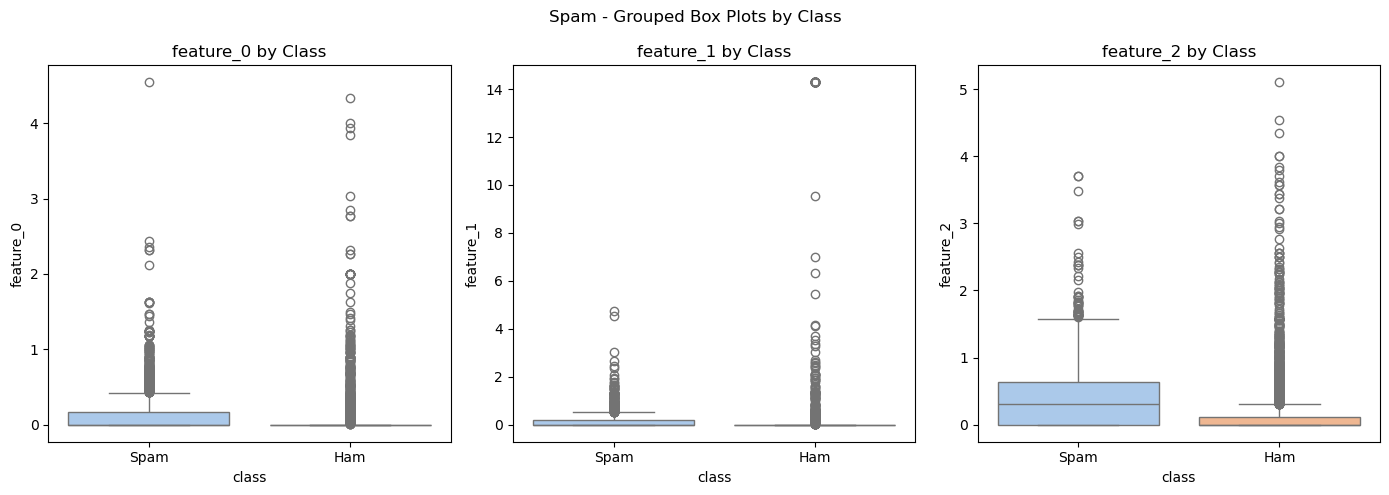


Outlier Detection using IQR (first 10 features):
feature_0: 1053 outliers
feature_1: 898 outliers
feature_2: 338 outliers
feature_3: 47 outliers
feature_4: 501 outliers
feature_5: 999 outliers
feature_6: 807 outliers
feature_7: 824 outliers
feature_8: 773 outliers
feature_9: 852 outliers


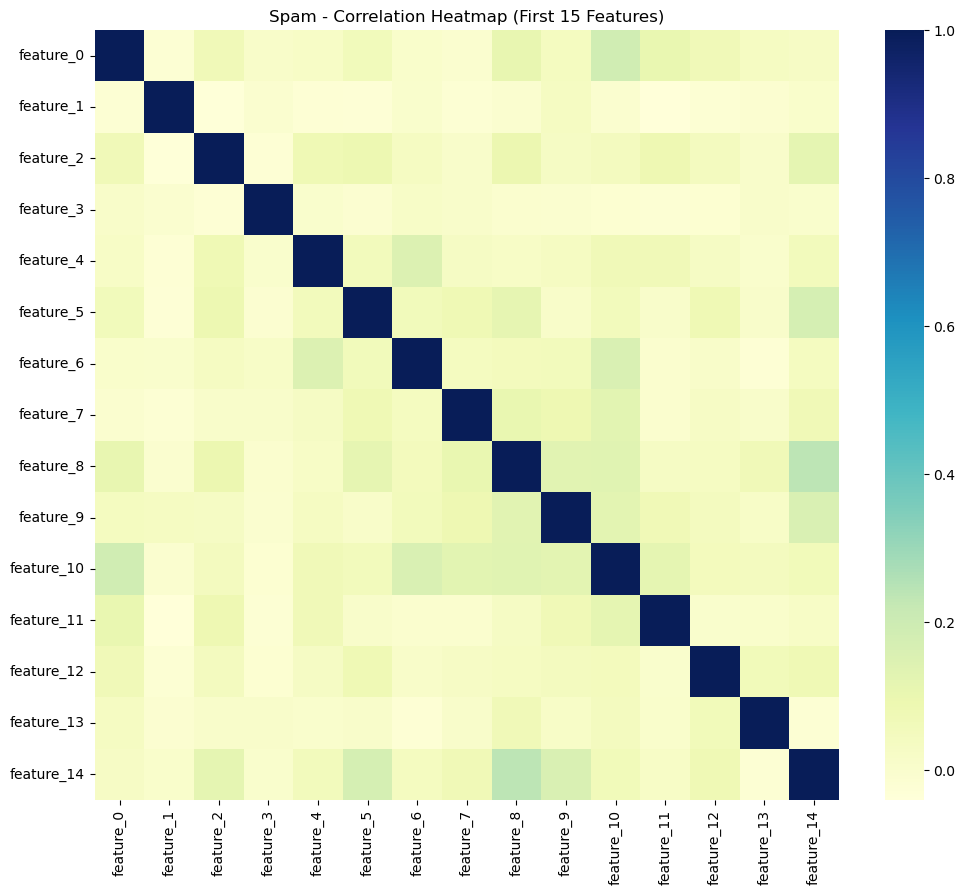

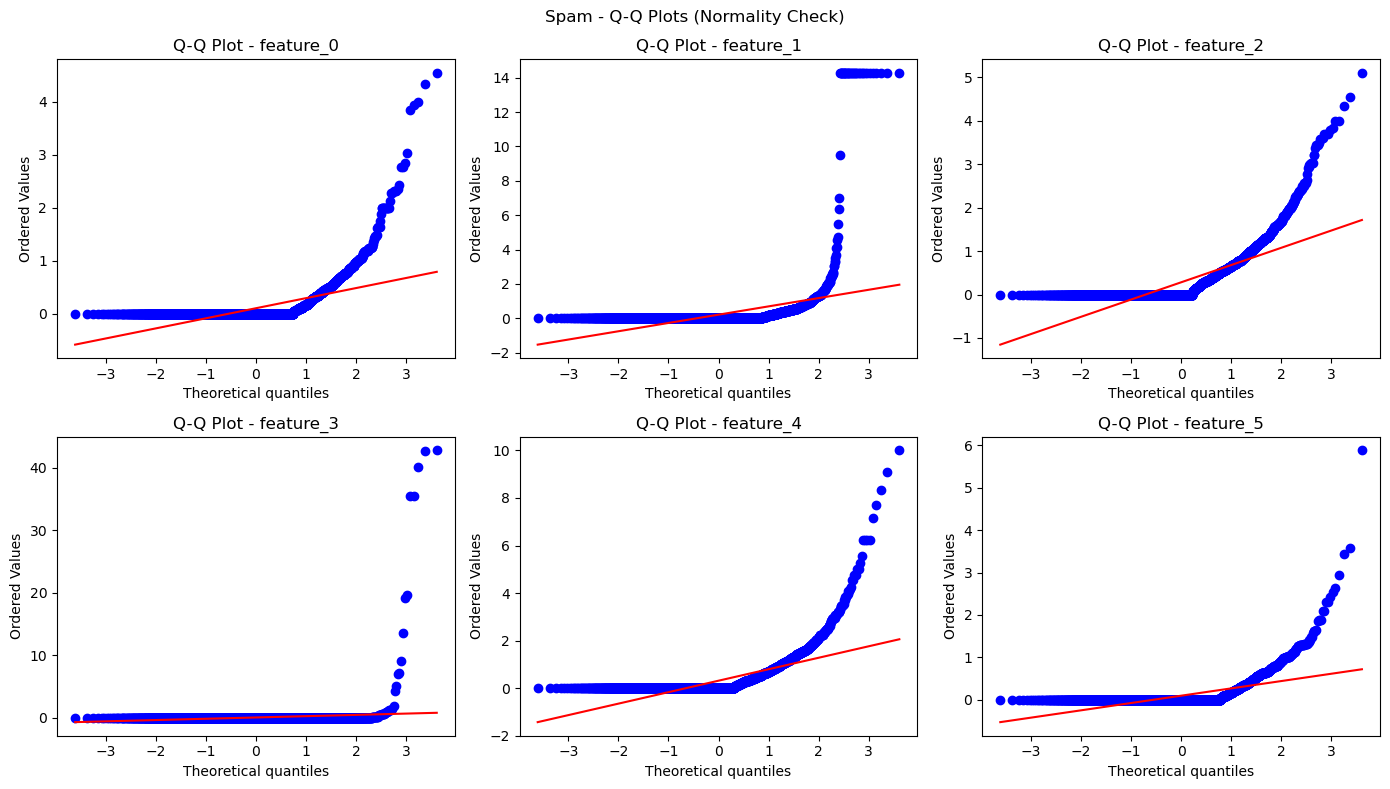

In [20]:
# ============================================================
# EDA - EMAIL SPAM CLASSIFICATION

col_names = [f'feature_{i}' for i in range(57)] + ['label']
df = pd.read_csv('spambase.data', header=None, names=col_names)
df['class'] = df['label'].map({0: 'Ham', 1: 'Spam'})

print("Shape:", df.shape)
print("\nClass Distribution:\n", df['class'].value_counts())
print("\nMissing Values:", df.isnull().sum().sum())
print("\nSummary Statistics:\n", df.describe())

# -------------------------------
# Class Distribution
# -------------------------------
plt.figure(figsize=(5, 4))
sns.countplot(
    x='class',
    hue='class',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Spam vs Ham - Class Distribution")
plt.ylabel("Count")
plt.show()

# -------------------------------
# Histograms
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i in range(6):
    ax = axes[i // 3, i % 3]
    df[f'feature_{i}'].hist(
        bins=30,
        ax=ax,
        color='mediumpurple',
        edgecolor='black'
    )
    ax.set_title(f"Histogram - feature_{i}")

plt.suptitle("Spam - Feature Histograms (Sample)")
plt.tight_layout()
plt.show()

# -------------------------------
# Box Plots (Outlier Detection)
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i in range(6):
    ax = axes[i // 3, i % 3]
    sns.boxplot(y=df[f'feature_{i}'], ax=ax, color='lightcoral')
    ax.set_title(f"Box Plot - feature_{i}")

plt.suptitle("Spam - Box Plots (Outlier Detection)")
plt.tight_layout()
plt.show()

# -------------------------------
# Grouped Box Plots
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i in range(3):
    sns.boxplot(
        x='class',
        y=f'feature_{i}',
        hue='class',
        data=df,
        ax=axes[i],
        palette='pastel',
        legend=False
    )
    axes[i].set_title(f"feature_{i} by Class")

plt.suptitle("Spam - Grouped Box Plots by Class")
plt.tight_layout()
plt.show()

# -------------------------------
# Outlier Detection using IQR
# -------------------------------
print("\nOutlier Detection using IQR (first 10 features):")

for i in range(10):
    col = f'feature_{i}'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    print(f"{col}: {len(outliers)} outliers")

# -------------------------------
# Correlation Heatmap
# -------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    df[[f'feature_{i}' for i in range(15)]].corr(),
    cmap='YlGnBu',
    annot=False
)
plt.title("Spam - Correlation Heatmap (First 15 Features)")
plt.show()

# -------------------------------
# Q-Q Plots
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i in range(6):
    ax = axes[i // 3, i % 3]
    stats.probplot(df[f'feature_{i}'], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot - feature_{i}")

plt.suptitle("Spam - Q-Q Plots (Normality Check)")
plt.tight_layout()
plt.show()

Shape: (42000, 785)
Classes: [0 1 2 3 4 5 6 7 8 9]

Class Distribution:
 label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

Missing Values: 0

Summary Stats (first 5 pixels):
               label   pixel0   pixel1   pixel2   pixel3
count  42000.000000  42000.0  42000.0  42000.0  42000.0
mean       4.456643      0.0      0.0      0.0      0.0
std        2.887730      0.0      0.0      0.0      0.0
min        0.000000      0.0      0.0      0.0      0.0
25%        2.000000      0.0      0.0      0.0      0.0
50%        4.000000      0.0      0.0      0.0      0.0
75%        7.000000      0.0      0.0      0.0      0.0
max        9.000000      0.0      0.0      0.0      0.0


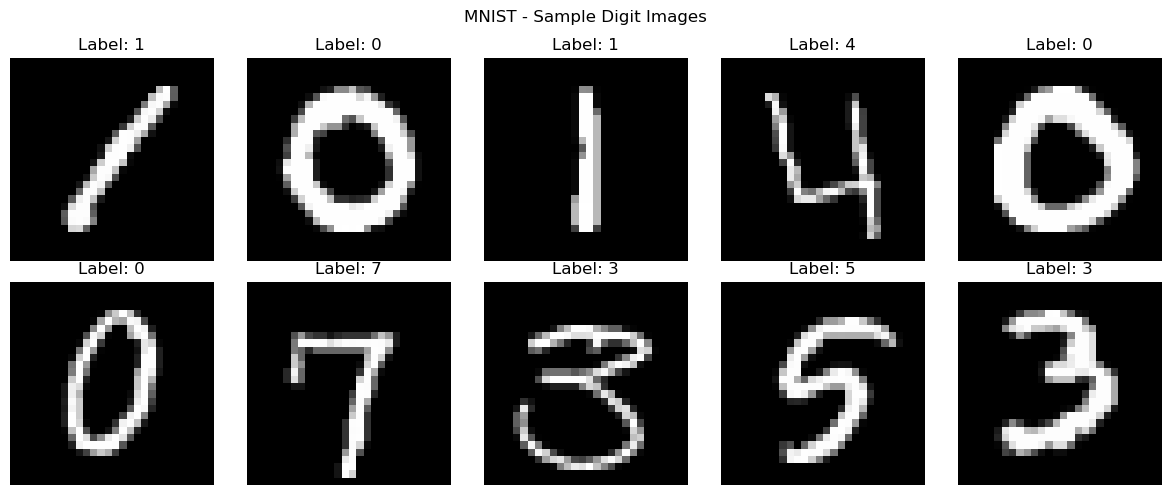

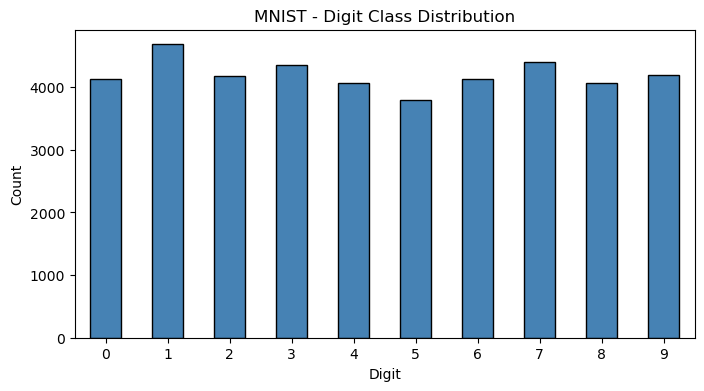

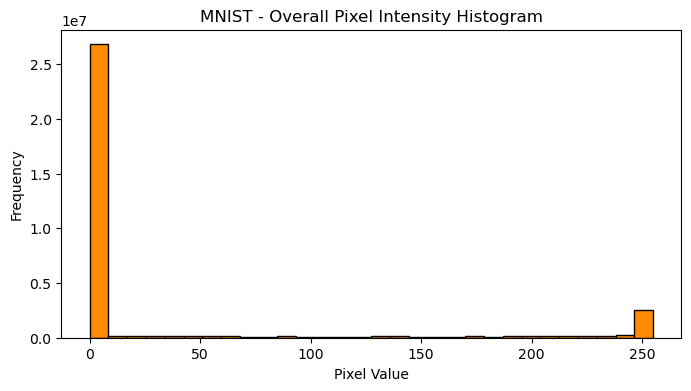

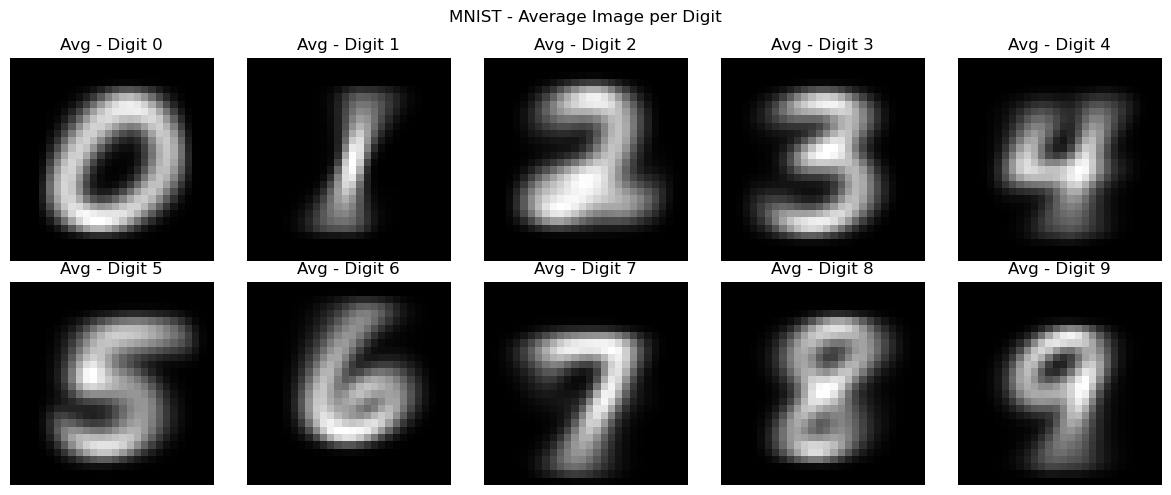

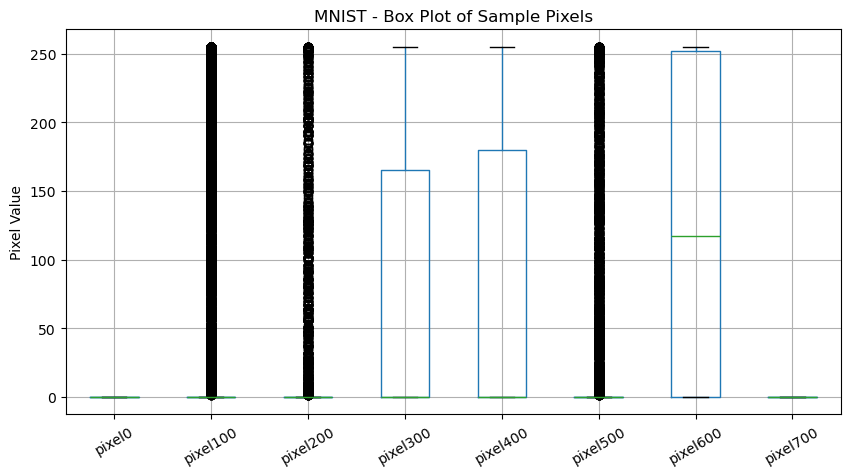

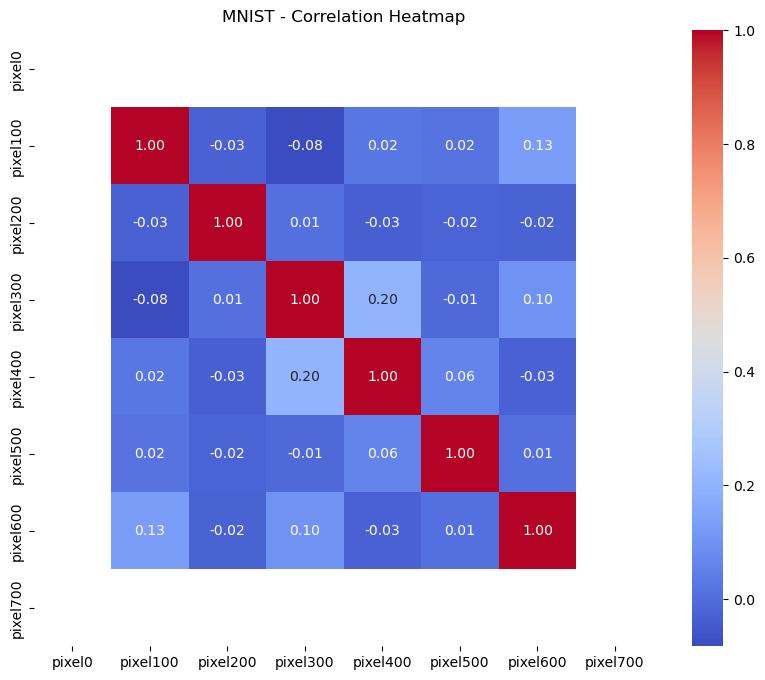

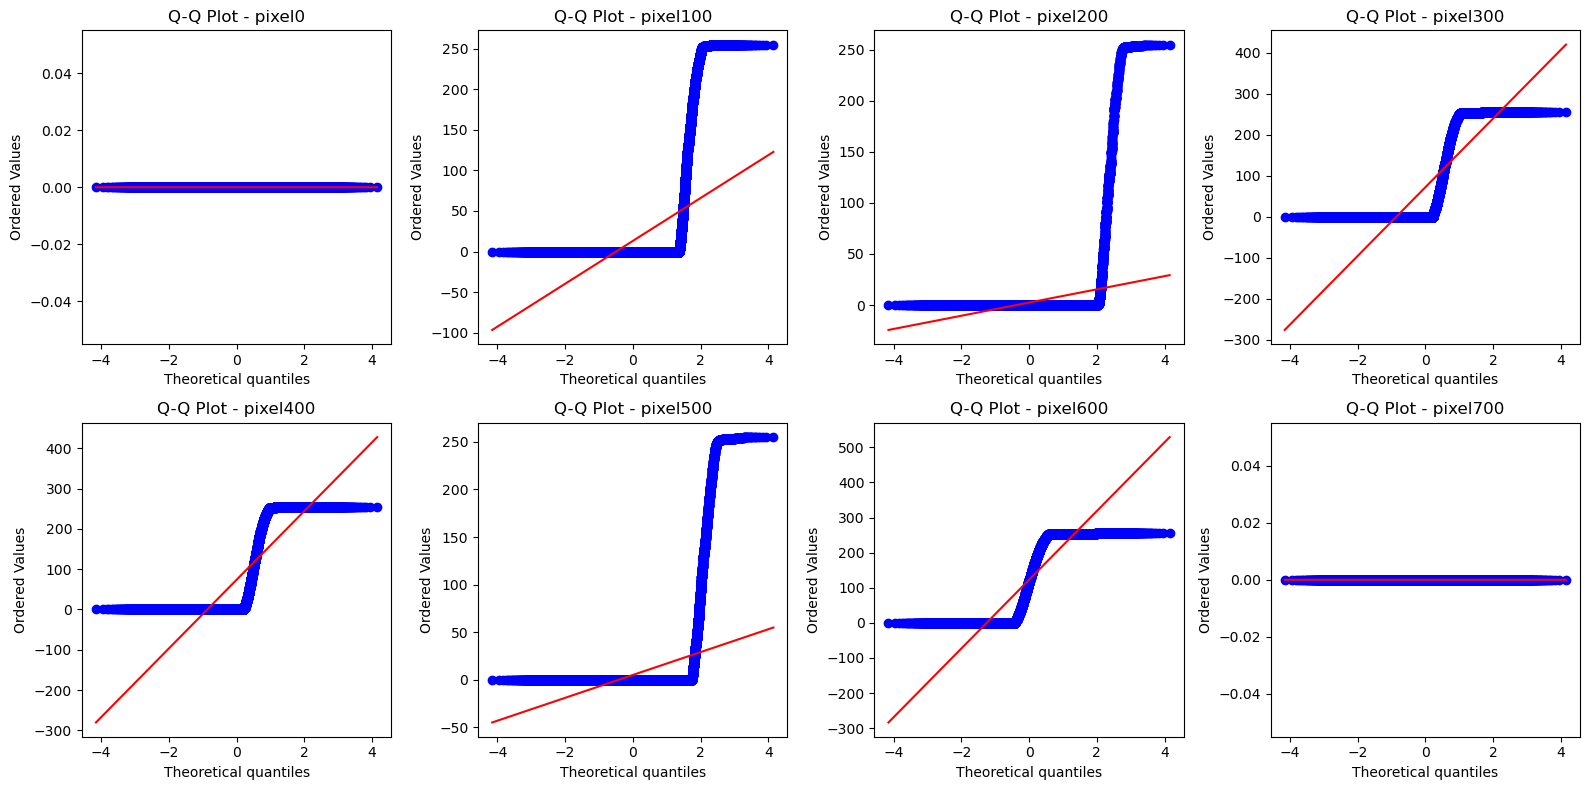

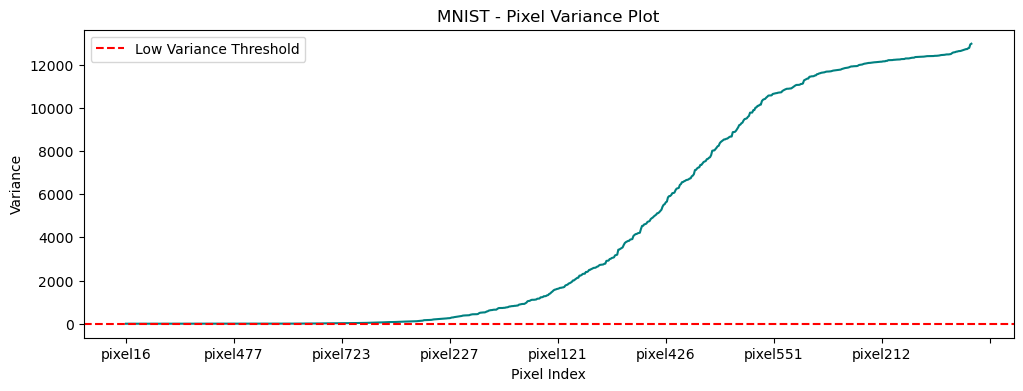


Low variance pixels: 79


In [29]:
# ============================================================
# EDA - MNIST HANDWRITTEN DIGITS (CSV VERSION)

# Load CSV
df = pd.read_csv("mnisttrain.csv")   # Change path if needed

# Separate features and labels
X = df.drop("label", axis=1).values
y = df["label"].values

print("Shape:", df.shape)
print("Classes:", np.unique(y))
print("\nClass Distribution:\n", df['label'].value_counts().sort_index())
print("\nMissing Values:", df.isnull().sum().sum())
print("\nSummary Stats (first 5 pixels):\n", df.iloc[:, :5].describe())

# -------------------------------------------------
# Sample Images
# -------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = X[i].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.suptitle("MNIST - Sample Digit Images")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Class Distribution
# -------------------------------------------------
plt.figure(figsize=(8,4))

pd.Series(y).value_counts().sort_index().plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title("MNIST - Digit Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# -------------------------------------------------
# Pixel Histogram
# -------------------------------------------------
plt.figure(figsize=(8,4))

plt.hist(
    X.flatten(),
    bins=30,
    color='darkorange',
    edgecolor='black'
)

plt.title("MNIST - Overall Pixel Intensity Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# -------------------------------------------------
# Average Image per Digit
# -------------------------------------------------
fig, axes = plt.subplots(2,5, figsize=(12,5))

for digit, ax in zip(range(10), axes.flat):
    avg_image = X[y == digit].mean(axis=0).reshape(28,28)
    ax.imshow(avg_image, cmap='gray')
    ax.set_title(f"Avg - Digit {digit}")
    ax.axis('off')

plt.suptitle("MNIST - Average Image per Digit")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Box Plot of Sample Pixels
# -------------------------------------------------
sample_pixels = [f'pixel{i}' for i in range(0,784,100)]

pixel_df = pd.DataFrame(
    X[:, ::100],
    columns=sample_pixels
)

plt.figure(figsize=(10,5))
pixel_df.boxplot()

plt.title("MNIST - Box Plot of Sample Pixels")
plt.ylabel("Pixel Value")
plt.xticks(rotation=30)
plt.show()

# -------------------------------------------------
# Correlation Heatmap
# -------------------------------------------------
plt.figure(figsize=(10,8))

sns.heatmap(
    pixel_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("MNIST - Correlation Heatmap")
plt.show()

# -------------------------------------------------
# Q-Q Plots
# -------------------------------------------------
fig, axes = plt.subplots(2,4, figsize=(16,8))

for i, col in enumerate(pixel_df.columns[:8]):
    ax = axes[i//4, i%4]
    stats.probplot(pixel_df[col], dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot - {col}")

plt.tight_layout()
plt.show()

# -------------------------------------------------
# Pixel Variance
# -------------------------------------------------
pixel_variance = df.drop("label", axis=1).var().sort_values()

plt.figure(figsize=(12,4))

pixel_variance.plot(
    kind='line',
    color='teal'
)

plt.title("MNIST - Pixel Variance Plot")
plt.xlabel("Pixel Index")
plt.ylabel("Variance")

plt.axhline(
    pixel_variance.quantile(0.1),
    color='red',
    linestyle='--',
    label='Low Variance Threshold'
)

plt.legend()
plt.show()

low_var_pixels = pixel_variance[
    pixel_variance < pixel_variance.quantile(0.1)
].index.tolist()

print(f"\nLow variance pixels: {len(low_var_pixels)}")